# Apriori Cadena Detallista

# Librerías

In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import networkx as nx

# Lectura de dataset

In [4]:
datos = pd.read_csv("../data/data/processed/detallista.csv", delimiter=",")
datos.head()

,Invoice,Reglas
0,489434,"15CM CHRISTMAS GLASS BALL 20 LIGHTS,PINK CHERR..."
1,489435,"CAT BOWL,DOG BOWL , CHASING BALL DESIGN,HEART ..."
2,489436,"DOOR MAT BLACK FLOCK,LOVE BUILDING BLOCK WORD,..."
3,489437,"CHRISTMAS CRAFT HEART DECORATIONS,CHRISTMAS CR..."
4,489438,"DINOSAURS WRITING SET,SET OF MEADOW FLOWER S..."


In [5]:
df_reglas_detallista = datos[["Reglas"]]
df_reglas_detallista.head()

,Reglas
0,"15CM CHRISTMAS GLASS BALL 20 LIGHTS,PINK CHERR..."
1,"CAT BOWL,DOG BOWL , CHASING BALL DESIGN,HEART ..."
2,"DOOR MAT BLACK FLOCK,LOVE BUILDING BLOCK WORD,..."
3,"CHRISTMAS CRAFT HEART DECORATIONS,CHRISTMAS CR..."
4,"DINOSAURS WRITING SET,SET OF MEADOW FLOWER S..."


In [6]:
data = list(df_reglas_detallista["Reglas"].apply(lambda x:x.split(",") ))
data

[['15CM CHRISTMAS GLASS BALL 20 LIGHTS',
  'PINK CHERRY LIGHTS',
  'WHITE CHERRY LIGHTS',
  'RECORD FRAME 7" SINGLE SIZE',
  'STRAWBERRY CERAMIC TRINKET BOX',
  'PINK DOUGHNUT TRINKET POT',
  'SAVE THE PLANET MUG',
  'FANCY FONT HOME SWEET HOME DOORMAT'],
 ['CAT BOWL',
  'DOG BOWL ',
  ' CHASING BALL DESIGN',
  'HEART MEASURING SPOONS LARGE',
  'LUNCHBOX WITH CUTLERY FAIRY CAKES'],
 ['DOOR MAT BLACK FLOCK',
  'LOVE BUILDING BLOCK WORD',
  'HOME BUILDING BLOCK WORD',
  'ASSORTED COLOUR BIRD ORNAMENT',
  'PEACE WOODEN BLOCK LETTERS',
  'CHRISTMAS CRAFT WHITE FAIRY',
  'HEART IVORY TRELLIS LARGE',
  'HEART FILIGREE DOVE LARGE',
  'FULL ENGLISH BREAKFAST PLATE',
  'PIZZA PLATE IN BOX',
  'BLACK DINER WALL CLOCK',
  'SET OF 3 BLACK FLYING DUCKS',
  'AREA PATROLLED METAL SIGN',
  'PLEASE ONE PERSON  METAL SIGN',
  'BATH BUILDING BLOCK WORD',
  'CLASSIC WHITE FRAME',
  'SMALL MARSHMALLOWS PINK BOWL',
  'BISCUITS SMALL BOWL LIGHT BLUE',
  'SCOTTIE DOG HOT WATER BOTTLE'],
 ['CHRISTMAS CRAFT HEA

In [7]:
a = TransactionEncoder()
a_data = a.fit(data).transform(data)
df = pd.DataFrame(a_data,columns=a.columns_)
df = df.replace(False,0)
df

,,0,1,1 HANGER,10 COLOURS - SPACEBOY,2,3,3 HANGER,3 TIER,3 TIER MINT/IVORY,...,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE DOUBLE PLANTER,ZINC HEART LATTICE PLANTER BOWL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC HEART LATTICE TRAY OVAL,ZINC METAL HEART DECORATION,ZINC POLICE BOX LANTERN,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,pack/12
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23582,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23583,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23584,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
23585,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df = apriori(df, min_support = 0.02, use_colnames = True, verbose = 1)
df

C:\Users\gilar\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Processing 81 combinations | Sampling itemset size 3e 2


,support,itemsets
0,0.027346,frozenset({})
1,0.028533,frozenset({6 RIBBONS RUSTIC CHARM})
2,0.048417,frozenset({60 TEATIME FAIRY CAKE CASES})
3,0.02955,frozenset({72 SWEETHEART FAIRY CAKE CASES})
4,0.029423,frozenset({ANTIQUE SILVER TEA GLASS ETCHED})
...,...,...
123,0.020859,"frozenset({HEART OF WICKER LARGE, HEART OF WIC..."
124,0.022216,"frozenset({HOME BUILDING BLOCK WORD, LOVE BUIL..."
125,0.030949,"frozenset({RED HANGING HEART T-LIGHT HOLDER, W..."
126,0.027303,"frozenset({STRAWBERRY CERAMIC TRINKET BOX, SWE..."


In [10]:
#Veamos nuestros valores de interpretación usando la función de regla asociativa.
df_ar = association_rules(df, metric = "confidence", min_threshold = 0.2)
df_ar

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({PACK OF 72 RETRO SPOT CAKE CASES}),frozenset({60 TEATIME FAIRY CAKE CASES}),0.049561,0.048417,0.020308,0.409752,8.463064,1.0,0.017908,1.612176,0.927824,0.261463,0.379720,0.414596
1,frozenset({60 TEATIME FAIRY CAKE CASES}),frozenset({PACK OF 72 RETRO SPOT CAKE CASES}),0.048417,0.049561,0.020308,0.419440,8.463064,1.0,0.017908,1.637106,0.926707,0.261463,0.389166,0.414596
2,frozenset({HEART OF WICKER LARGE}),frozenset({HEART OF WICKER SMALL}),0.042523,0.037436,0.020859,0.490528,13.103164,1.0,0.019267,1.889338,0.964705,0.352941,0.470714,0.523860
3,frozenset({HEART OF WICKER SMALL}),frozenset({HEART OF WICKER LARGE}),0.037436,0.042523,0.020859,0.557191,13.103164,1.0,0.019267,2.162281,0.959606,0.352941,0.537525,0.523860
4,frozenset({HOME BUILDING BLOCK WORD}),frozenset({LOVE BUILDING BLOCK WORD}),0.050197,0.040743,0.022216,0.442568,10.862478,1.0,0.020170,1.720849,0.955925,0.323257,0.418892,0.493916
5,frozenset({LOVE BUILDING BLOCK WORD}),frozenset({HOME BUILDING BLOCK WORD}),0.040743,0.050197,0.022216,0.545265,10.862478,1.0,0.020170,2.088697,0.946503,0.323257,0.521233,0.493916
6,frozenset({RED HANGING HEART T-LIGHT HOLDER}),frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),0.043032,0.131979,0.030949,0.719212,5.449422,1.0,0.025270,3.091371,0.853210,0.214832,0.676519,0.476856
7,frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),frozenset({RED HANGING HEART T-LIGHT HOLDER}),0.131979,0.043032,0.030949,0.234500,5.449422,1.0,0.025270,1.250122,0.940639,0.214832,0.200078,0.476856
8,frozenset({STRAWBERRY CERAMIC TRINKET BOX}),frozenset({SWEETHEART CERAMIC TRINKET BOX}),0.061983,0.036122,0.027303,0.440492,12.194714,1.0,0.025064,1.722726,0.978658,0.385629,0.419525,0.598181
9,frozenset({SWEETHEART CERAMIC TRINKET BOX}),frozenset({STRAWBERRY CERAMIC TRINKET BOX}),0.036122,0.061983,0.027303,0.755869,12.194714,1.0,0.025064,3.842261,0.952399,0.385629,0.739737,0.598181


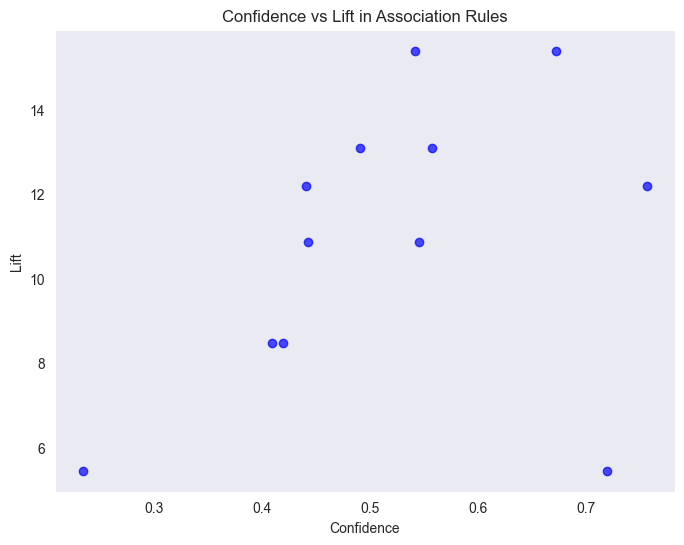

In [11]:
# Scatter plot of confidence vs lift
plt.figure(figsize=(8,6))
plt.scatter(df_ar['confidence'], df_ar['lift'], alpha=0.7, color='b')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Confidence vs Lift in Association Rules')
plt.grid()
plt.show()

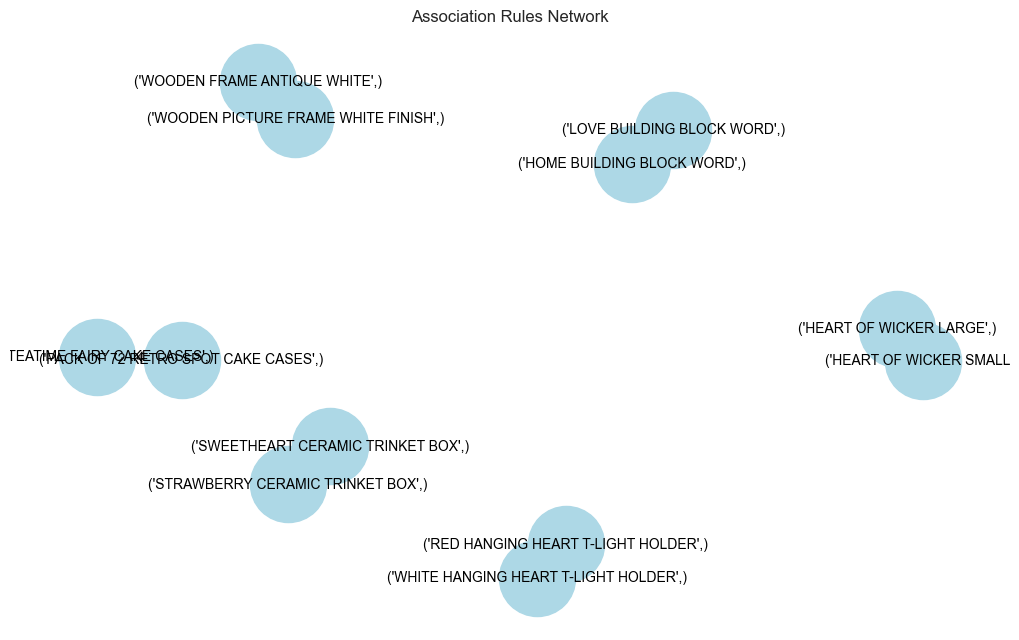

In [12]:
# Visualizing association rules as a network graph
G = nx.DiGraph()
for _, row in df_ar.iterrows():
    G.add_edge(tuple(row['antecedents']), tuple(row['consequents']), weight=row['confidence'])
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=3000, font_size=10)
edge_labels = {(tuple(row['antecedents']), tuple(row['consequents'])): f"{row['confidence']:.2f}"
               for _, row in df_ar.iterrows()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Association Rules Network")
plt.show()